In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

2026-03-02 18:18:11.229017: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 18:18:11.311704: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/master_nilesh/Tensorflow/TF_GPU/lib/python3.12/site-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.0)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top
2026-03-02 18:18:12.725622: I tensorflow/core/util/port.cc:153] oneDNN cu

In [2]:
class DataProcessor:
    def __init__(self, url):
        column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                        'Acceleration', 'Model Year', 'Origin']
        # Fetching from UCI pointed by "url"
        self.raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)
        self.scaler = StandardScaler()

    def clean_and_prepare(self):
        # Remove null values

        print(self.raw_dataset.head())
        df = self.raw_dataset.dropna()
        
        # One-hot encode 'Origin' 
        df = pd.get_dummies(df, columns=['Origin'], prefix='', prefix_sep='')
        
        # Split features and labels
        X = df.drop('MPG', axis=1)
        y = df['MPG']
        
        # Split into Train, Val, Test (80-10-10%)
        X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
        
        # Feature Scaling
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        X_test_scaled = self.scaler.transform(X_test)
        
        return (X_train_scaled, y_train), (X_val_scaled, y_val), (X_test_scaled, y_test)

In [3]:
# 1. Initialize and Process Data
data_url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
processor = DataProcessor(data_url)
train, val, test = processor.clean_and_prepare()

    MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   Model Year  Origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  


In [4]:
class FuelPredictorModel:
    def __init__(self, input_shape):
        self.model = self._build_model(input_shape)

    def _build_model(self, input_shape):
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu', input_shape=[input_shape]),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(1) # Single output for regression
        ])

        model.compile(
            optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
            loss='mse',
            metrics=['mae', 'mse'] # Mean Absolute Error & Mean Squared Error
        )
        return model

    def train(self, train_data, val_data, epochs=100):
        X_train, y_train = train_data
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
        
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            validation_data=val_data,
            verbose=1,
            callbacks=[early_stop]
        )
        return history

In [5]:
# 2. Build and Train
input_dim = train[0].shape[1]
predictor = FuelPredictorModel(input_dim)
print("Training model...")
history = predictor.train(train, val, epochs=20)

# 3. Evaluate on Test Set
test_results = predictor.model.evaluate(test[0], test[1], verbose=0)
print(f"\nTest Metrics - MAE: {test_results[1]:.2f} MPG")

/home/master_nilesh/Tensorflow/TF_GPU/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772475497.518763   14908 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5518 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Training model...
Epoch 1/20


2026-03-02 18:18:19.069649: I external/local_xla/xla/service/service.cc:163] XLA service 0x74c068009c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-02 18:18:19.069690: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-03-02 18:18:19.091623: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-02 18:18:19.176182: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


 1/10 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 461.1479 - mae: 20.2879 - mse: 461.1479

I0000 00:00:1772475500.096983   15009 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - loss: 594.0230 - mae: 23.0617 - mse: 594.0230 - val_loss: 466.7570 - val_mae: 20.5845 - val_mse: 466.7570
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 540.1799 - mae: 21.8633 - mse: 540.1799 - val_loss: 416.6668 - val_mae: 19.3340 - val_mse: 416.6668
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 482.2915 - mae: 20.5346 - mse: 482.2915 - val_loss: 360.2173 - val_mae: 17.8474 - val_mse: 360.2173
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 417.2273 - mae: 18.9289 - mse: 417.2273 - val_loss: 298.8158 - val_mae: 16.0774 - val_mse: 298.8158
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 346.3139 - mae: 17.0237 - mse: 346.3139 - val_loss: 235.9564 - val_mae: 14.0631 - val_mse: 235.9564
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 274.1460 - mae: 14.9260 - mse: 274.1460 - val_loss: 175.2888 - val_mae: 11.9426 - val_mse: 175.2888
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - los

In [6]:
# 4. Inferencing on "Unknown" Data
# Simulating a new car: 4 cylinders, 121 displacement, 110 hp, 2800 weight, 15.4 accel, 81 built year
unknown_car = np.array([[4, 121.0, 110.0, 2800.0, 15.4, 81, 0, 1, 0]]) 
unknown_car_scaled = processor.scaler.transform(unknown_car)

prediction = predictor.model.predict(unknown_car_scaled)
print(f"Predicted Fuel Efficiency: {prediction[0][0]:.2f} MPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step

/home/master_nilesh/Tensorflow/TF_GPU/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Predicted Fuel Efficiency: 26.40 MPG


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step


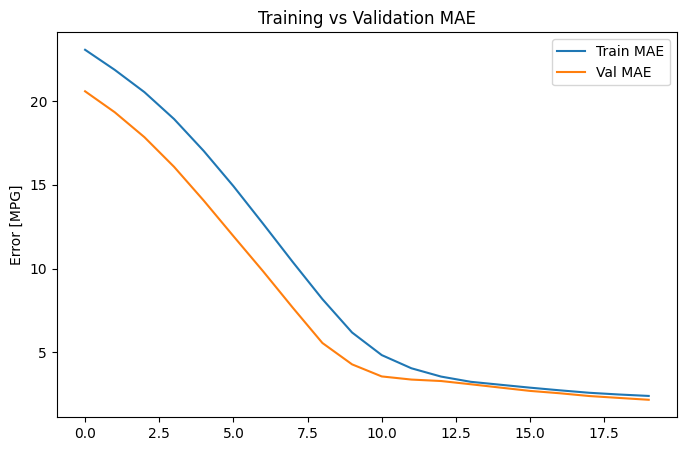

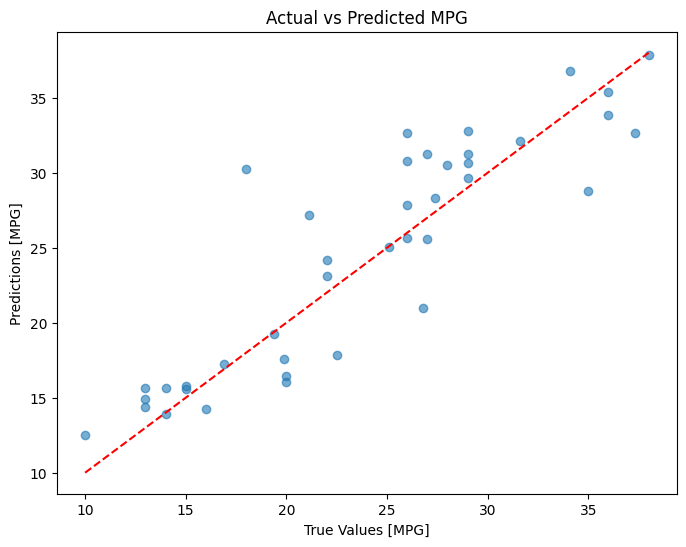

In [7]:
# 5. Plot Training Metrics
plt.figure(figsize=(8, 5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Training vs Validation MAE')
plt.ylabel('Error [MPG]')
plt.legend()
plt.savefig('training_history.png')

# 4. Inferencing on Unknown Data
test_predictions = predictor.model.predict(test[0]).flatten()
plt.figure(figsize=(8, 6))
plt.scatter(test[1], test_predictions, alpha=0.6)
plt.plot([test[1].min(), test[1].max()], [test[1].min(), test[1].max()], 'r--')
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.title('Actual vs Predicted MPG')
plt.savefig('prediction_accuracy.png')

In [ ]:
# Notes - 

# Variance is higher in the testing phase signifying high complexity of model capturing noise